In [ ]:
import tensorflow as tf
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense,SimpleRNN,Embedding

In [2]:
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=10000)

# Pad sequences to have the same length
X_train=pad_sequences(X_train,maxlen=100)
X_test=pad_sequences(X_test,maxlen=100)

In [3]:
model=Sequential()
model.add(Embedding(10000,32,input_length=100))
model.add(SimpleRNN(5,return_sequences=True))
model.add(SimpleRNN(5))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 32)           320000    
                                                                 
 simple_rnn (SimpleRNN)      (None, 100, 5)            190       
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 5)                 55        
                                                                 
 dense (Dense)               (None, 1)                 6         
                                                                 
Total params: 320,251
Trainable params: 320,251
Non-trainable params: 0
_________________________________________________________________


In [4]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [5]:
history=model.fit(X_train,y_train,epochs=10,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/10
782/782 [==============================] - 112s 140ms/step - loss: 0.6811 - accuracy: 0.5543 - val_loss: 0.6493 - val_accuracy: 0.6133
Epoch 2/10
782/782 [==============================] - 108s 138ms/step - loss: 0.5713 - accuracy: 0.7051 - val_loss: 0.5678 - val_accuracy: 0.7040
Epoch 3/10
782/782 [==============================] - 115s 147ms/step - loss: 0.4191 - accuracy: 0.8175 - val_loss: 0.5063 - val_accuracy: 0.7684
Epoch 4/10
782/782 [==============================] - 131s 167ms/step - loss: 0.3170 - accuracy: 0.8712 - val_loss: 0.5536 - val_accuracy: 0.7517
Epoch 5/10
782/782 [==============================] - 112s 143ms/step - loss: 0.2421 - accuracy: 0.9091 - val_loss: 0.5566 - val_accuracy: 0.7695
Epoch 6/10
782/782 [==============================] - 120s 154ms/step - loss: 0.2443 - accuracy: 0.9084 - val_loss: 0.5799 - val_accuracy: 0.7562
Epoch 7/10
782/782 [==============================] - 110s 140ms/step - loss: 0.1741 - accuracy: 0.9395 - val_loss: 0.6349 -

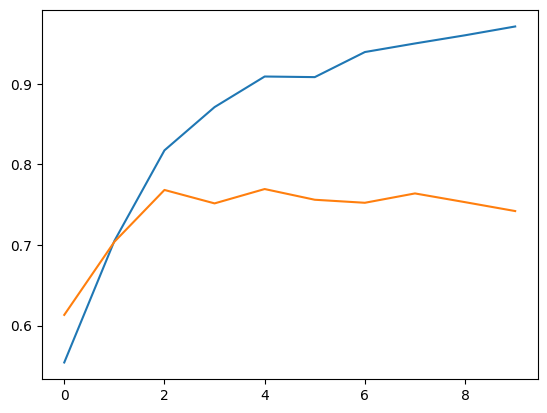

In [6]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])